# Modèles de Référence (Baselines) : Stateful & Walk-Forward

Ce notebook démontre l'utilisation de l'architecture **Stateful** (les modèles mémorisent leur propre historique pour construire leurs variables temporelles) et l'importance d'éviter les fuites de données (Data Leakage) via des **`assert`** de sécurité.

Puisque les modèles ne peuvent plus tricher en lisant le futur, nous devons utiliser une validation **Rolling (Walk-Forward)** où le modèle avance pas à pas.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Ajout robuste du dossier src au PYTHONPATH
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root + '/src')

from evaluation.evaluator import TimeSeriesEvaluator
from models.baselines import LastWeekPersistenceRegressor, YesterdayPersistenceRegressor, LinearRegressor, SimilarDayRegressor

# 1. Chargement des données pures
df = pd.read_csv('../data/processed/dataset_final.csv')


### 1. Initialisation de l'Évaluateur Universel

Nous découpons les données en chronologie stricte :
- **Train** : 2016 à fin 2023
- **Val** : Année 2024
- **Test** : 2025 et plus

In [2]:
evaluator = TimeSeriesEvaluator(df)

val_start = pd.to_datetime('2024-01-01').tz_localize('Europe/Paris')
test_start = pd.to_datetime('2025-01-01').tz_localize('Europe/Paris')

df_train, df_val, df_test = evaluator.split_data(val_start, test_start)


--- Découpage Temporel ---
Train: 70127 lignes (74.4%) |
Val: 8784 lignes (9.3%) |
Test: 15313 lignes (16.3%)



### 2. Le Danger du Data Leak (Fuite de Données)

Si l'on essaie de demander au modèle de prédire toute l'année 2024 d'un seul coup (batch `predict`), il va planter ! Pourquoi ? 

Parce que nous avons implémenté des **assertions de sécurité strictes** (`assert len(df_test) <= 24`) qui bloquent physiquement le modèle s'il tente de prédire un horizon plus grand que ses Lags. Sans ça, un modèle comme `LinearRegressor` lirait la vraie température et la vraie consommation du mois de Janvier pour prédire le mois de Février.

In [3]:
print("Démonstration de la sécurité anti Data-Leak :\n")
model_test = YesterdayPersistenceRegressor()
model_test.fit(df_train)

try:
    # On essaye de tricher en prédisant une année entière
    model_test.predict(df_val)
except AssertionError as e:
    print("BLOQUÉ ! Le modèle a refusé de s'exécuter :")
    print(f"-> {e}")

Démonstration de la sécurité anti Data-Leak :

BLOQUÉ ! Le modèle a refusé de s'exécuter :
-> Data Leak : Prediction horizon exceeds 1 day.


### 3. La Vraie Évaluation : Rolling Walk-Forward
Puisqu'on ne peut avancer que de 24h en 24h, nous utilisons la validation glissante. L'évaluateur va démarrer au 1er Janvier, s'entraîner sur l'historique, prédire le lendemain, et avancer d'un jour. 
*Pour la `LastWeekPersistenceRegressor`, on peut avancer de semaine en semaine (24h).*  
*Pour les autres, on avance de jour en jour (24h).*


In [ ]:
model_hebdo = LastWeekPersistenceRegressor()
evaluator.rolling_validation(model_hebdo, df_train, df_val, step_size_days=1)
model_yesterday = YesterdayPersistenceRegressor()
evaluator.rolling_validation(model_yesterday, df_train, df_val, step_size_days=1)
model_similar = SimilarDayRegressor(k=4, temp_weight=0.5)
evaluator.rolling_validation(model_similar, df_train, df_val, step_size_days=1)
model_lr = LinearRegressor(
	features_cols=[
		'consommation_mw_meme_heure_derniere_connue',
        'consommation_mw_derniere_connue',
		'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
		'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances',
		'temperature_c_pondere_pop_meme_heure_derniere_connue',
		'temperature_c_pondere_pop_derniere_connue',
		'temperature_c_pondere_pop_moins_7', 'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366'
	]
)
evaluator.rolling_validation(model_lr, df_train, df_val, step_size_days=1)



========== ROLLING VALIDATION : LastWeekPersistenceRegressor ==========
Évaluation sur 8784 lignes | Pas de réentraînement: 1 jours | 367 itérations
Progression: 2024-12-31 00:00...

SCORE GLOBAL ROLLING (1 jours) : MAE = 3246.44 MW | RMSE = 4856.93 MW | MAPE = 6.08%


========== ROLLING VALIDATION : YesterdayPersistenceRegressor ==========
Évaluation sur 8784 lignes | Pas de réentraînement: 1 jours | 367 itérations
Progression: 2024-12-31 00:00...

SCORE GLOBAL ROLLING (1 jours) : MAE = 3126.20 MW | RMSE = 4272.77 MW | MAPE = 6.29%


========== ROLLING VALIDATION : LinearRegressor ==========
Évaluation sur 8784 lignes | Pas de réentraînement: 1 jours | 367 itérations
Progression: 2024-01-01 00:00...

KeyboardInterrupt: 

### 4. Visualisation
La validation rolling a sauvegardé ses prédictions jour par jour. Superposons-les avec la réalité pour voir quel modèle suit le mieux les vrais pics de consommation !

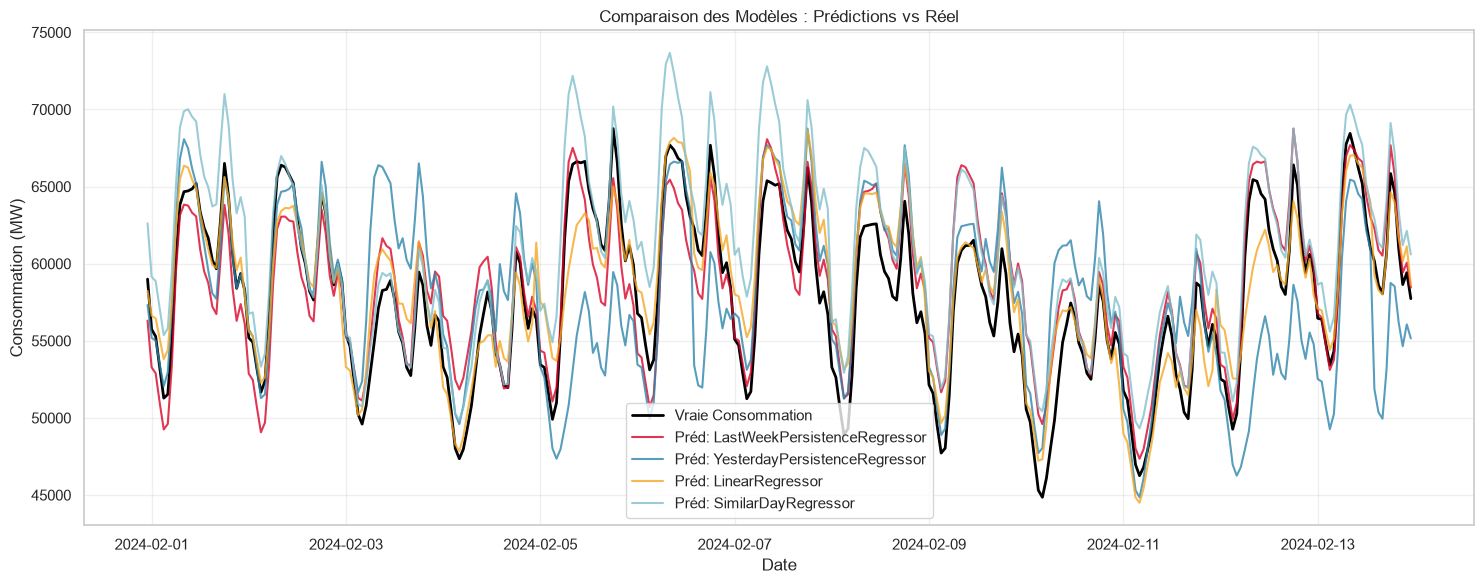

In [ ]:
# Zoomons sur le mois de Février 2024 (le début de notre set de validation)
start_zoom = pd.to_datetime('2024-02-01').tz_localize('Europe/Paris')
end_zoom = pd.to_datetime('2024-02-14').tz_localize('Europe/Paris')

evaluator.plot_predictions(df_val, start_date=start_zoom, end_date=end_zoom)


## Grid Search Hyperparamètres
Nous avons implémenté une fonction `grid_search_rolling_validation` directement dans `TimeSeriesEvaluator`.
Elle nous permet de tester une grille de paramètres (ex: `n_weeks` pour le modèle ComparableDays) en appliquant systématiquement la validation walk-forward sécurisée pour chaque combinaison.

In [ ]:
# Recherche des meilleurs paramètres pour le modèle 'Moyenne des jours comparables'
param_grid = {
    'n_candidates': [2, 3, 4, 5, 8]  # Teste l'impact de remonter jusqu'à 8 semaines
}

best_params, best_score, results = evaluator.grid_search_rolling_validation(
    SimilarDayRegressor,
    param_grid,
    df_train,
    df_val,
    step_size_days=1,
    metric='MAE'
)


========== GRID SEARCH : SimilarDayRegressor ==========
Total combinations to evaluate: 5

--- Combination 1/5 : {'n_candidates': 2} ---


TypeError: SimilarDayRegressor.__init__() got an unexpected keyword argument 'n_candidates'